# Notebook 06 — Visualization: Cube Files & Population Analysis

**MOLEKUL | Phases 6 & 7**

---

Numbers alone are not chemistry. This notebook connects the abstract matrices of an
RHF calculation to two physically meaningful outputs that chemists actually use:

1. **Cube files** — volumetric data (electron density, molecular orbitals) readable by
   VMD, VESTA, and Avogadro.
2. **Mulliken population analysis** — approximate atomic charges and the molecular
   dipole moment.

**What you will learn:**
1. The Gaussian CUBE file format and how to generate density/orbital cubes.
2. How the electron density $\rho(\mathbf{r}) = \sum_{\mu\nu} P_{\mu\nu} \phi_\mu(\mathbf{r}) \phi_\nu(\mathbf{r})$ is evaluated on a grid.
3. Mulliken charges: derivation, caveats, and practical use.
4. The molecular dipole moment from the quantum-mechanical formula.

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from molekul.atoms import Atom
from molekul.molecule import Molecule
from molekul.basis_sto3g import STO3G
from molekul.rhf import rhf_scf
from molekul.cube import (
    make_grid, grid_points, eval_basis_grid,
    eval_density_grid, eval_orbital_grid,
    export_density, export_orbital,
)
from molekul.population import mulliken_populations, dipole_moment
from molekul.constants import BOHR_TO_ANGSTROM

h2o = Molecule(
    atoms=[
        Atom.from_angstrom("O",  0.0000,  0.0000,  0.1173),
        Atom.from_angstrom("H",  0.7572,  0.0000, -0.4692),
        Atom.from_angstrom("H", -0.7572,  0.0000, -0.4692),
    ],
    name="water",
)

basis = STO3G
result = rhf_scf(h2o, basis)
print(f"RHF energy: {result.energy_total:.6f} Ha")


RHF energy: -74.963023 Ha


## 1. The electron density

The one-electron density $\rho(\mathbf{r})$ is the probability of finding any electron at
position $\mathbf{r}$:
$$\rho(\mathbf{r}) = \sum_{\mu\nu} P_{\mu\nu}\, \phi_\mu(\mathbf{r})\, \phi_\nu(\mathbf{r})$$

Properties:
- $\rho(\mathbf{r}) \geq 0$ everywhere (it is a probability density).
- $\int \rho(\mathbf{r})\,d^3r = N_e$ (integrates to the number of electrons).
- $\rho$ has peaks at nuclear positions (from the cusp condition).

The density is the observable that DFT is built on — in DFT, all ground-state
properties are functionals of $\rho$ alone (Hohenberg-Kohn theorem).

In [2]:
# Build a grid and evaluate the electron density

origin, steps, (nx, ny, nz) = make_grid(h2o, margin=3.0, step=0.3)
pts = grid_points(origin, steps, (nx, ny, nz))   # (n_pts, 3)
print(f"Grid: {nx}\u00d7{ny}\u00d7{nz} = {nx*ny*nz} points")

phi = eval_basis_grid(basis, h2o, pts)            # (n_basis, n_pts)
rho_flat = eval_density_grid(result.density_matrix, phi)   # (n_pts,)
rho = rho_flat.reshape(nx, ny, nz)                          # (nx, ny, nz)

print(f"rho shape: {rho.shape}")
print(f"max density: {rho.max():.4f} e/bohr\u00b3")

n_el_grid = rho_flat.sum() * steps[0]**3
print(f"\u222b\u03c1 dV \u2248 {n_el_grid:.2f} e  (exact: {h2o.n_electrons})")


Grid: 31×21×25 = 16275 points
rho shape: (31, 21, 25)
max density: 50.0460 e/bohr³
∫ρ dV ≈ 10.16 e  (exact: 10)


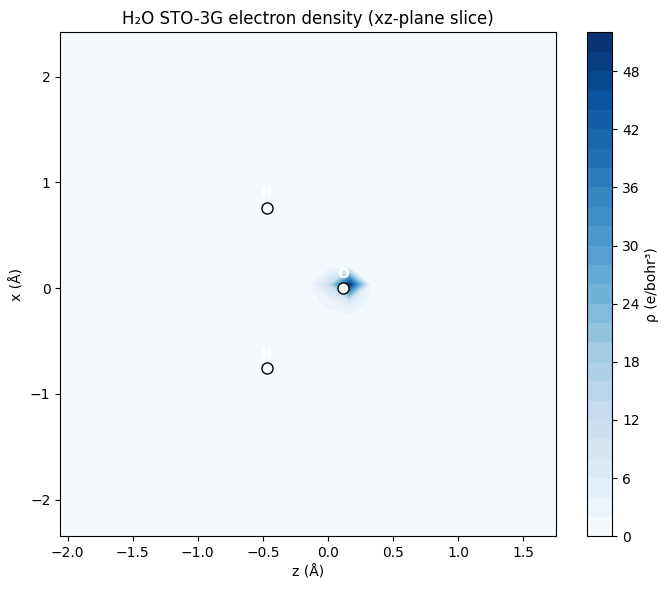

In [3]:
iy_mid = ny // 2
rho_slice = rho[:, iy_mid, :]   # (nx, nz)

x_axis = (origin[0] + np.arange(nx) * steps[0]) * BOHR_TO_ANGSTROM
z_axis = (origin[2] + np.arange(nz) * steps[2]) * BOHR_TO_ANGSTROM

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(z_axis, x_axis, rho_slice, levels=30, cmap="Blues")
plt.colorbar(cf, ax=ax, label="\u03c1 (e/bohr\u00b3)")
for atom in h2o.atoms:
    ax.plot(atom.coords[2]*BOHR_TO_ANGSTROM, atom.coords[0]*BOHR_TO_ANGSTROM,
            "wo", ms=8, markeredgecolor="k")
    ax.annotate(atom.symbol,
                xy=(atom.coords[2]*BOHR_TO_ANGSTROM, atom.coords[0]*BOHR_TO_ANGSTROM+0.1),
                ha="center", color="white", fontweight="bold")
ax.set_xlabel("z (\u00c5)")
ax.set_ylabel("x (\u00c5)")
ax.set_title("H\u2082O STO-3G electron density (xz-plane slice)")
plt.tight_layout()
plt.show()


## 2. The Gaussian CUBE format

The CUBE format stores volumetric data on a regular 3D grid. The header describes the grid
geometry; the data block lists scalar values row by row.

```
MOLECULE_NAME
Generated by MOLEKUL
   3   -5.000   -5.000   -5.000     ← NATOMS  XORIG  YORIG  ZORIG (bohr)
  40    0.250    0.000    0.000     ← NX  DX  0  0
  40    0.000    0.250    0.000
  40    0.000    0.000    0.250
   8    8.000    0.000    0.000    0.2217  ← Z  charge  X  Y  Z
   1    1.000    1.430    0.000   -0.8866
   1    1.000   -1.430    0.000   -0.8866
   0.0000e+00  3.1215e-03  ...            ← data (6 per line)
```

Tools that read CUBE: VMD, VESTA, Avogadro, Jmol, ChimeraX.

In [4]:
cube_dir = Path("../outputs/cubes")
cube_dir.mkdir(parents=True, exist_ok=True)

n_occ = h2o.n_electrons // 2

density_path = str(cube_dir / "h2o_density.cube")
export_density(density_path, h2o, basis, result, margin=3.0, step=0.2)
print(f"Wrote density cube: {density_path}")

homo_path = str(cube_dir / "h2o_homo.cube")
export_orbital(homo_path, h2o, basis, result, n_occ - 1, margin=3.0, step=0.2)
print(f"Wrote HOMO cube:    {homo_path}")

lumo_path = str(cube_dir / "h2o_lumo.cube")
export_orbital(lumo_path, h2o, basis, result, n_occ, margin=3.0, step=0.2)
print(f"Wrote LUMO cube:    {lumo_path}")


Wrote density cube: ../outputs/cubes/h2o_density.cube
Wrote HOMO cube:    ../outputs/cubes/h2o_homo.cube
Wrote LUMO cube:    ../outputs/cubes/h2o_lumo.cube


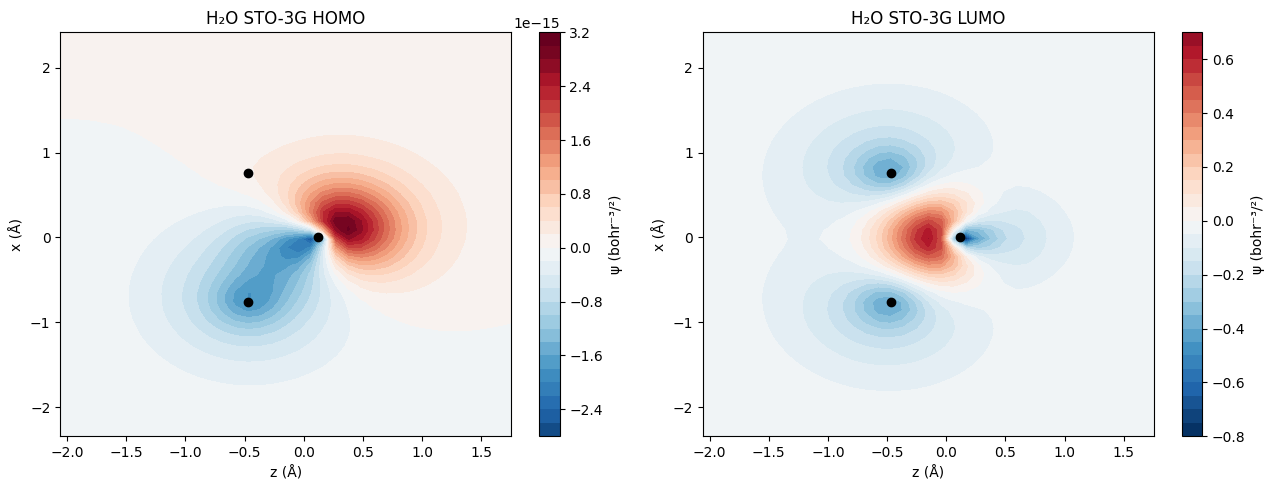

In [5]:

n_occ = h2o.n_electrons // 2
origin_f, steps_f, (nx_f, ny_f, nz_f) = make_grid(h2o, margin=3.0, step=0.2)
pts_f  = grid_points(origin_f, steps_f, (nx_f, ny_f, nz_f))
phi_f  = eval_basis_grid(basis, h2o, pts_f)   # (n_basis, n_pts)

homo_flat = eval_orbital_grid(result.mo_coefficients, n_occ - 1, phi_f)
lumo_flat = eval_orbital_grid(result.mo_coefficients, n_occ, phi_f)
homo_3d   = homo_flat.reshape(nx_f, ny_f, nz_f)
lumo_3d   = lumo_flat.reshape(nx_f, ny_f, nz_f)

iy_mid = ny_f // 2
x_ax = (origin_f[0] + np.arange(nx_f) * steps_f[0]) * BOHR_TO_ANGSTROM
z_ax = (origin_f[2] + np.arange(nz_f) * steps_f[2]) * BOHR_TO_ANGSTROM

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, orb_3d, title in [(ax1, homo_3d, "HOMO"), (ax2, lumo_3d, "LUMO")]:
    sl = orb_3d[:, iy_mid, :]
    vmax = np.abs(sl).max()
    cf = ax.contourf(z_ax, x_ax, sl, levels=30, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    plt.colorbar(cf, ax=ax, label="\u03c8 (bohr\u207b\u00b3/\u00b2)")
    for atom in h2o.atoms:
        ax.plot(atom.coords[2]*BOHR_TO_ANGSTROM, atom.coords[0]*BOHR_TO_ANGSTROM, "ko", ms=6)
    ax.set_xlabel("z (\u00c5)")
    ax.set_ylabel("x (\u00c5)")
    ax.set_title(f"H\u2082O STO-3G {title}")
plt.tight_layout()
plt.show()


## 2b. Interactive 3D view (optional)

The 2D slices above are quick, but orbitals are 3D objects. If you have **py3Dmol**
installed (`pip install py3Dmol`, included in the `notebooks` extra) the cell below
renders the molecule together with the HOMO as a pair of isosurfaces
(blue = positive lobe, red = negative lobe) that you can rotate with the mouse.

It reuses the cube file written above. If py3Dmol is missing the cell prints an
install hint and is safe to skip — nothing else depends on it.

In [6]:
def show_orbital_3d(molecule, cube_path, isoval=0.02, width=420, height=420):
    """Render a molecule + an orbital cube as +/- isosurfaces with py3Dmol."""
    import py3Dmol
    from molekul.constants import BOHR_TO_ANGSTROM

    # molecule as an XYZ block (Angstrom)
    lines = [str(molecule.n_atoms), ""]
    for at in molecule.atoms:
        x, y, z = at.coords * BOHR_TO_ANGSTROM
        lines.append(f"{at.symbol} {x:.6f} {y:.6f} {z:.6f}")
    xyz = "\n".join(lines)

    with open(cube_path) as fh:
        cube = fh.read()

    view = py3Dmol.view(width=width, height=height)
    view.addModel(xyz, "xyz")
    view.setStyle({"stick": {"radius": 0.10}, "sphere": {"scale": 0.25}})
    view.addVolumetricData(cube, "cube", {"isoval":  isoval, "color": "blue", "opacity": 0.85})
    view.addVolumetricData(cube, "cube", {"isoval": -isoval, "color": "red",  "opacity": 0.85})
    view.zoomTo()
    return view

# `homo_path` was written a few cells above (export_orbital -> .cube).
try:
    show_orbital_3d(h2o, homo_path).show()
except ImportError:
    print("py3Dmol not installed - skipping the interactive 3D view.")
    print('Install it with:  pip install py3Dmol   (or  pip install -e ".[notebooks]")')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 3. Mulliken population analysis

Mulliken (1955) proposed partitioning the electrons among atoms by looking at the diagonal
of the product $\mathbf{PS}$:

$$N_\mu = (\mathbf{PS})_{\mu\mu} \quad \text{(gross orbital population)}$$
$$N_A = \sum_{\mu \in A} N_\mu \quad \text{(gross atomic population)}$$
$$q_A = Z_A - N_A \quad \text{(Mulliken charge)}$$

Check: $\sum_A N_A = \text{tr}[\mathbf{PS}] = N_e$ ✓

**Important caveats:**
- Mulliken charges are **not observable** — they depend on the choice of basis set.
- With small (STO-3G, 6-31G*) bases they give qualitatively reasonable charges.
- With diffuse (aug-cc-pV*Z) bases they can be nonsensical (negative or > Z).
- Better alternatives: NPA/NBO, Hirshfeld, QTAIM — but all require additional tools.

In [7]:
from molekul.integrals import build_overlap

S = build_overlap(basis, h2o)
P = result.density_matrix
pop = mulliken_populations(P, S, basis, h2o)

print("Mulliken population analysis (H\u2082O/STO-3G):")
print(f"{'Atom':>6}  {'Z':>4}  {'Population':>12}  {'Charge':>8}")
print("-" * 38)
for i, atom in enumerate(h2o.atoms):
    N = pop.gross_atomic_pop[i]
    q = pop.mulliken_charges[i]
    print(f"{i+1:>4}:{atom.symbol:2s}  {atom.Z:>4d}  {N:>12.4f}  {q:>+8.4f}")
print("-" * 38)
print(f"  Total electrons: {pop.total_electrons:.4f}  (expected {h2o.n_electrons})")


Mulliken population analysis (H₂O/STO-3G):
  Atom     Z    Population    Charge
--------------------------------------
   1:O      8        8.3657   -0.3657
   2:H      1        0.8171   +0.1829
   3:H      1        0.8171   +0.1829
--------------------------------------
  Total electrons: 10.0000  (expected 10)


## 4. Molecular dipole moment

The dipole moment is:
$$\boldsymbol{\mu} = \sum_A Z_A \mathbf{R}_A - \sum_{\mu\nu} P_{\mu\nu} \langle\phi_\mu|\mathbf{r}|\phi_\nu\rangle$$

The nuclear part is classical; the electronic part requires the **dipole integrals**
$D^c_{\mu\nu} = \langle\phi_\mu|r_c|\phi_\nu\rangle$.

MOLEKUL computes these using the identity $r_c \cdot g(l_c) = g(l_c+1) + A_c \cdot g(l_c)$,
which recycles the overlap integral infrastructure — no new recurrence is needed.

Conversion: 1 $ea_0$ (atomic units) = 2.5418 Debye.

In [8]:
dip = dipole_moment(P, basis, h2o)

print("Dipole moment (H\u2082O/STO-3G):")
print(f"  \u03bc_x = {dip.total_au[0]:+.6f} ea\u2080  = {dip.total_debye[0]:+.4f} D")
print(f"  \u03bc_y = {dip.total_au[1]:+.6f} ea\u2080  = {dip.total_debye[1]:+.4f} D")
print(f"  \u03bc_z = {dip.total_au[2]:+.6f} ea\u2080  = {dip.total_debye[2]:+.4f} D")
print(f"  |\u03bc| = {dip.magnitude_debye:.4f} D")
print(f"  (Experimental: 1.8546 D)")


Dipole moment (H₂O/STO-3G):
  μ_x = +0.000000 ea₀  = +0.0000 D
  μ_y = +0.000000 ea₀  = +0.0000 D
  μ_z = -0.678788 ea₀  = -1.7253 D
  |μ| = 1.7253 D
  (Experimental: 1.8546 D)


## 5. Basis set dependence of Mulliken charges

The Mulliken charges of water change visibly between basis sets —
a demonstration of their basis-set dependence.

In [9]:
from molekul.basis_631gstar import G631Star
from molekul.basis_ccpvdz import ccpVDZ
from molekul.integrals import build_overlap

for bname, b in [("STO-3G", STO3G), ("6-31G*", G631Star), ("cc-pVDZ", ccpVDZ)]:
    r   = rhf_scf(h2o, b)
    S_b = build_overlap(b, h2o)
    pop_b = mulliken_populations(r.density_matrix, S_b, b, h2o)
    dip_b = dipole_moment(r.density_matrix, b, h2o)
    q_O = pop_b.mulliken_charges[0]
    q_H = pop_b.mulliken_charges[1]
    print(f"{bname:8s}:  q(O) = {q_O:+.3f}  q(H) = {q_H:+.3f}"
          f"  |\u03bc| = {dip_b.magnitude_debye:.3f} D")
print("Experimental dipole: 1.8546 D")


STO-3G  :  q(O) = -0.366  q(H) = +0.183  |μ| = 1.725 D


6-31G*  :  q(O) = -0.866  q(H) = +0.433  |μ| = 2.226 D


cc-pVDZ :  q(O) = -0.303  q(H) = +0.152  |μ| = 2.614 D
Experimental dipole: 1.8546 D


---

## Exercises

**1.** Verify that $\int\rho(\mathbf{r})d^3r \approx N_e$ for your density cube by summing
the grid values times the voxel volume $dx^3$. How does the result change with
step sizes 0.5, 0.3, 0.2, 0.1 bohr?

**2.** The HOMO of H₂O should be a non-bonding oxygen lone-pair orbital. Examine the
contour plot and explain the nodal structure in terms of atomic symmetry.

**3.** Compute Mulliken charges for N₂ (homonuclear). What do you expect? What do you get?

**4.** Compute the dipole moment of CO in STO-3G. The experimental dipole is 0.112 D
(C end negative). Does MOLEKUL get the direction right? What does a wrong direction tell us
about the basis set?

**5.** (Advanced) Write a function that computes the **electron density difference**
$\Delta\rho = \rho_{\text{mol}} - \sum_A \rho_A^{\text{atom}}$ (where each atomic
density is computed from a separate RHF calculation for the isolated atom).
This "deformation density" highlights where bonds accumulate electron density.

---

## Summary

| Concept | Formula / note |
|---------|----------------|
| Electron density | $\rho(\mathbf{r}) = \sum_{\mu\nu} P_{\mu\nu}\phi_\mu\phi_\nu$; integrates to $N_e$ |
| CUBE file | 3D grid + header; readable by VMD, VESTA, Avogadro |
| Molecular orbital | $\psi_i(\mathbf{r}) = \sum_\mu C_{\mu i}\phi_\mu$ |
| Mulliken charge | $q_A = Z_A - \sum_{\mu\in A}(\mathbf{PS})_{\mu\mu}$; basis-dependent |
| Dipole moment | $\boldsymbol{\mu} = \sum_A Z_A\mathbf{R}_A - \sum_{\mu\nu}P_{\mu\nu}\mathbf{D}_{\mu\nu}$ |

The cube files written here can be loaded into VMD or VESTA to produce publication-quality
orbital and density plots — the kind that appear in most computational chemistry papers.